In [1]:
import re
import pickle
import efmtool
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [2]:
FIXED_UPTAKE = 10  # uptake fixed in uranium_v3.ipynb

In [3]:
with open('tested_growth_rates.pkl', 'rb') as f:
    simulated_mus = pickle.load(f)

In [4]:
c_sources = {
    "Geobacter": {"mEmC_1": "M_mal__45__L_e",
                  "mEmC_2": "M_mal__45__L_e",
                  "mEmC_3": "M_mal__45__L_e",
                  "mEmC_4": "M_mal__45__L_e",
                  "mEmC_5": "M_cit_e",
                  "mEmC_6": "M_cit_e",
                  "mE_1": "M_mal__45__L_e"},
    "Rhodoferax": {"mEmC_1": "M_fum_e",
                   "mEmC_3": "M_fum_e",
                   "mEmC_2": "M_cit_e",
                   "mEmC_4": "M_cit_e",
                   "mEmC_5": "M_mal__45__L_e",
                   "mEmC_6": "M_mal__45__L_e",
                   "mE_1": "M_ac_e"}
    }

In [5]:
growing_ecms = {}
for model in ["Rhodoferax", "Geobacter"]:
    print(f" * {model}")
    growing_ecms[model] = {}
    for code, growth_rates in simulated_mus.items():
        print(code)
        growing_ecms[model][code] = {}
        
        all_yields = []
        all_mus = []
        
        for mu in growth_rates:
            mu = round(mu, 2)
            print(f"Growth rate {mu}")
            ecms = pd.read_csv(f"results/{model}_{code}_{mu}_full_conversions.csv")
            
            # filter out ECMs that grow
            growing = ecms[ecms["objective"] > 1e-9]
            print(f"  * {len(growing)}/{len(ecms)} growing ECMs")

            # divide by constraint reaction - it must have flux of 1 so that constraints work
            growing = growing.div(growing["virtual_tag_R_constraint_reaction"], axis=0)

            # remove extreme fluxes
            growing = growing[(growing.abs() <= 1000).all(axis=1)]
            print(f"  * {len(growing)} growing ECMs after filtering extreme fluxes")

            # add back uptake reaction (not in the default ecmtool output because of bound-free form)
            growing[c_sources[model][code]] = -FIXED_UPTAKE - growing["M_fixed_uptake"]
            growing = growing.drop(columns=["M_fixed_uptake"])

            growing_ecms[model][code][mu] = growing

            growing.to_csv(f"results/growing_ecms_{model}_{code}_{mu}.csv")

            yields = growing["objective"] / (FIXED_UPTAKE + growing[c_sources[model][code]])
            
            all_yields.extend(abs(yields).tolist())
            all_mus.extend([mu] * len(yields))

        # plot_df = pd.DataFrame({"Biomass yield": all_yields, "mu": all_mus})
        # sns.stripplot(data=plot_df, x="mu", y="Biomass yield")
        # plt.title(f"{model} {code}")
        # plt.xlabel("Growth rate")
        # plt.show()

 * Rhodoferax
mEmC_1
Growth rate 0.66
  * 12/13 growing ECMs
  * 12 growing ECMs after filtering extreme fluxes
Growth rate 0.6
  * 70/71 growing ECMs
  * 70 growing ECMs after filtering extreme fluxes
Growth rate 0.54
  * 72/73 growing ECMs
  * 72 growing ECMs after filtering extreme fluxes
Growth rate 0.47
  * 72/73 growing ECMs
  * 72 growing ECMs after filtering extreme fluxes
Growth rate 0.4
  * 72/73 growing ECMs
  * 72 growing ECMs after filtering extreme fluxes
Growth rate 0.33
  * 190/191 growing ECMs
  * 190 growing ECMs after filtering extreme fluxes
Growth rate 0.27
  * 267/268 growing ECMs
  * 267 growing ECMs after filtering extreme fluxes
Growth rate 0.2
  * 319/320 growing ECMs
  * 319 growing ECMs after filtering extreme fluxes
mEmC_3
Growth rate 0.66
  * 12/13 growing ECMs
  * 12 growing ECMs after filtering extreme fluxes
Growth rate 0.6
  * 70/71 growing ECMs
  * 70 growing ECMs after filtering extreme fluxes
Growth rate 0.54
  * 72/73 growing ECMs
  * 72 growing EC

In [6]:
all_dimes = {"Rhodoferax": {
            "mEmC_1": {
                "uptakes": ["M_fe2_e"],#, "M_fum_e"],
                "secretion": ["M_mal__45__L_e"]},
            "mEmC_3": {
                "uptakes": ["M_fe2_e"],#, "M_fum_e"],
                "secretion": ["M_mal__45__L_e"]},
            "mEmC_2": {
                "uptakes": ["M_fe2_e"],#, "M_cit_e"],
                "secretion": ["M_mal__45__L_e"]},
            "mEmC_4": {
                "uptakes": ["M_fe2_e"],#, "M_cit_e"],
                "secretion": ["M_mal__45__L_e"]},
            "mEmC_5": {
                "uptakes": ["M_fe2_e"],#, "M_mal__45__L_e"],
                "secretion": []},
            "mEmC_6": {
                "uptakes": ["M_fe2_e", "M_co2_e"], # "M_mal__45__L_e",
                "secretion": []},
            "mE_1": {
                "uptakes": [],#"M_ac_e"],
                "secretion": []}
},
        "Geobacter": {
            "mEmC_1": {
                "uptakes": [],#"M_mal__45__L_e"],
                "secretion": ["M_fe2_e"]},
            "mEmC_2": {
                "uptakes": [],#["M_mal__45__L_e"],
                "secretion": ["M_fe2_e"]},
            "mEmC_3": {
                "uptakes": [],#["M_mal__45__L_e"],
                "secretion": ["M_fe2_e"]},
            "mEmC_4": {
                "uptakes": [],#["M_mal__45__L_e"],
                "secretion": ["M_fe2_e"]},
            "mEmC_5": {
                "uptakes": [],#["M_cit_e"],
                "secretion": ["M_mal__45__L_e", "M_fe2_e"]},
            "mEmC_6": {
                "uptakes": [],#["M_cit_e"],
                "secretion": ["M_mal__45__L_e", "M_fe2_e", "M_co2_e"]},
            "mE_1": {
                "uptakes": [],#["M_mal__45__L_e"],
                "secretion": ["M_ac_e"]}
        }}

#sec_only = ["M_h2_e"]

In [7]:
filtered_ecms = {}
for model, dimes in all_dimes.items():
    filtered_ecms[model] = {}
    for dime_number, dime in dimes.items():
        print(model, dime_number)

        filtered_ecms[model][dime_number] = {}
        for mu, ecms in growing_ecms[model][dime_number].items():

            # filter out ecms with a specific pattern
            sec_cols = dime["secretion"]
            filtered = ecms[(ecms[sec_cols] > 0).all(axis=1)]
            uptake_cols = dime["uptakes"]
            filtered = filtered[(filtered[uptake_cols] < 0).all(axis=1)]
            filtered = filtered.loc[:, (filtered != 0).any(axis=0)]
    
            # remove columns that are just zeros
            filtered_ecms[model][dime_number][mu] = filtered
    
            filtered.to_csv(f"results/filtered_ecms_{model}_{dime_number}_{mu}.csv")
    
            print(f"  {mu}: {len(filtered)}/{len(ecms)} ECMs")

Rhodoferax mEmC_1
  0.66: 1/12 ECMs
  0.6: 10/70 ECMs
  0.54: 12/72 ECMs
  0.47: 12/72 ECMs
  0.4: 12/72 ECMs
  0.33: 62/190 ECMs
  0.27: 66/267 ECMs
  0.2: 66/319 ECMs
Rhodoferax mEmC_3
  0.66: 1/12 ECMs
  0.6: 10/70 ECMs
  0.54: 12/72 ECMs
  0.47: 12/72 ECMs
  0.4: 12/72 ECMs
  0.33: 62/190 ECMs
  0.27: 66/267 ECMs
  0.2: 66/319 ECMs
Rhodoferax mEmC_2
  0.99: 1/13 ECMs
  0.9: 1/13 ECMs
  0.8: 1/13 ECMs
  0.7: 1/13 ECMs
  0.6: 4/44 ECMs
  0.5: 12/112 ECMs
  0.4: 22/188 ECMs
  0.3: 104/435 ECMs
Rhodoferax mEmC_4
  0.92: 1/13 ECMs
  0.84: 1/13 ECMs
  0.74: 1/13 ECMs
  0.65: 4/44 ECMs
  0.56: 8/76 ECMs
  0.47: 15/137 ECMs
  0.37: 25/207 ECMs
  0.28: 113/453 ECMs
Rhodoferax mEmC_5
  0.66: 12/12 ECMs
  0.6: 70/70 ECMs
  0.54: 72/72 ECMs
  0.47: 72/72 ECMs
  0.4: 72/72 ECMs
  0.33: 94/94 ECMs
  0.27: 154/154 ECMs
  0.2: 188/188 ECMs
Rhodoferax mEmC_6
  0.32: 4/44 ECMs
  0.29: 6/62 ECMs
  0.26: 10/94 ECMs
  0.23: 10/94 ECMs
  0.2: 12/108 ECMs
  0.16: 30/126 ECMs
  0.13: 40/164 ECMs
  0.1: 38

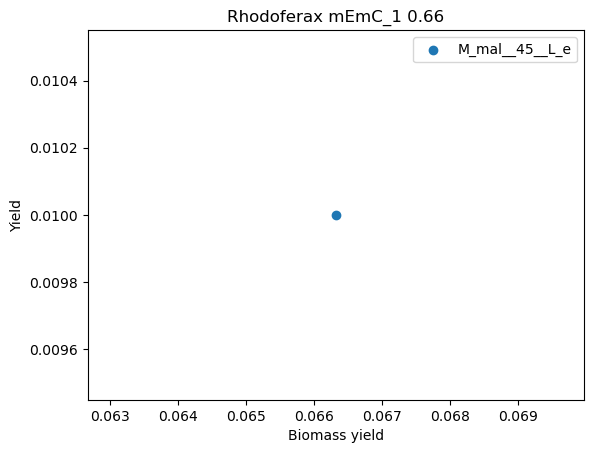

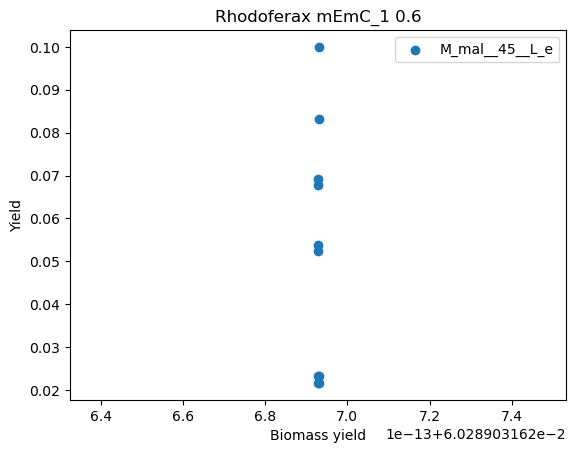

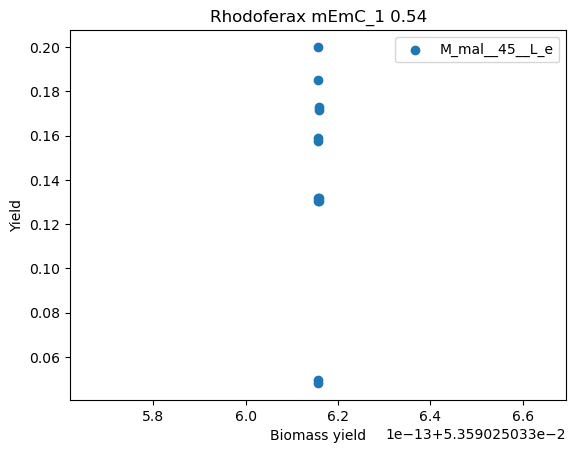

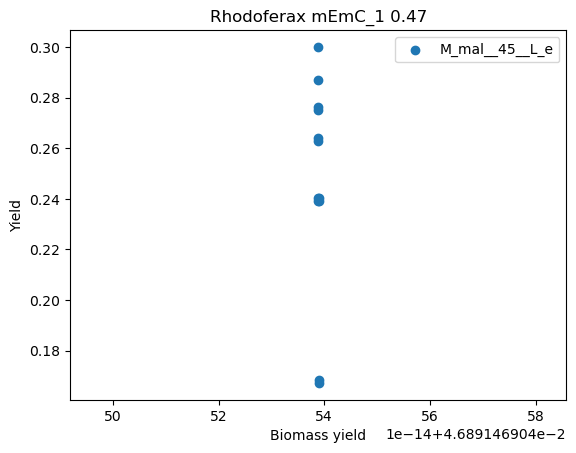

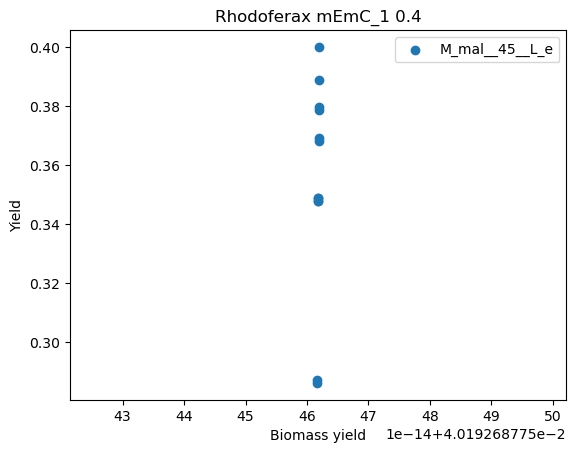

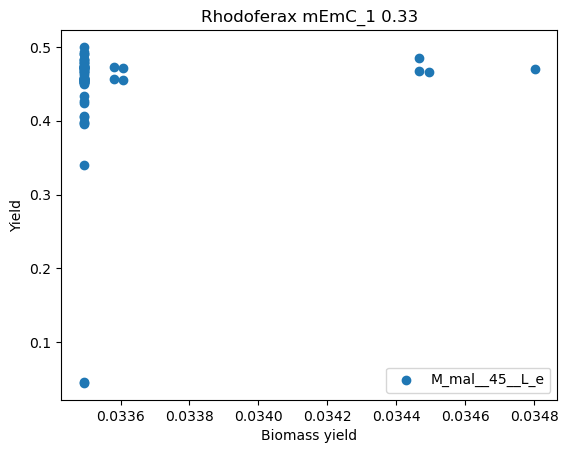

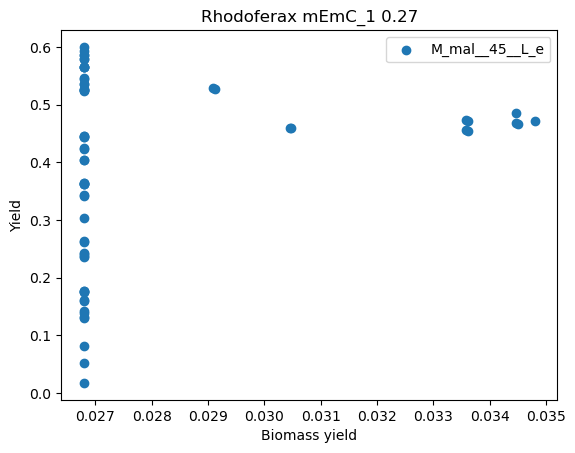

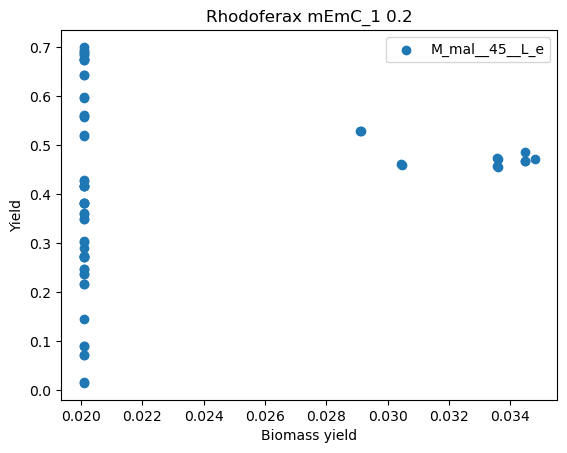

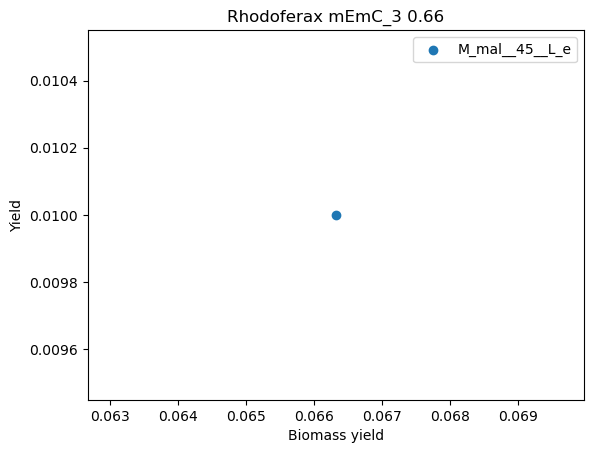

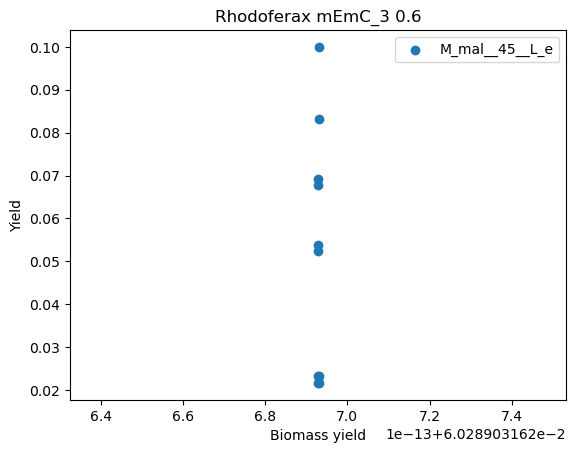

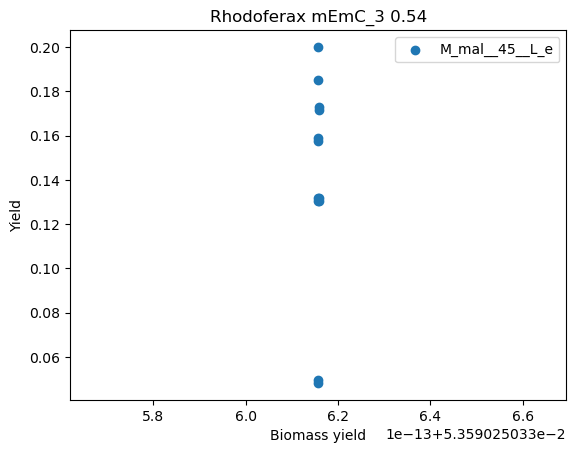

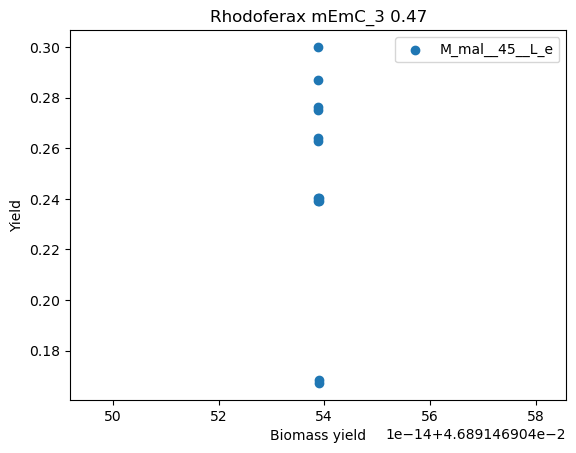

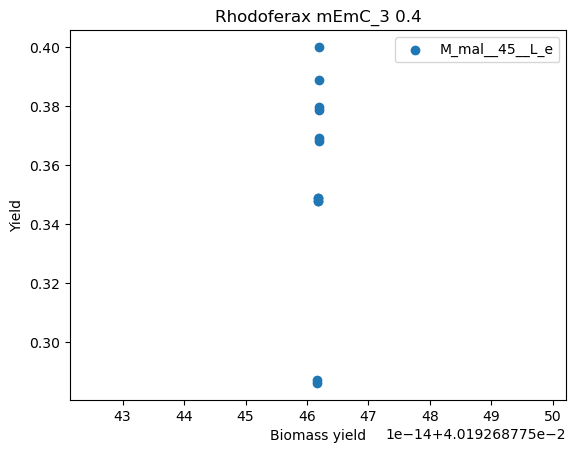

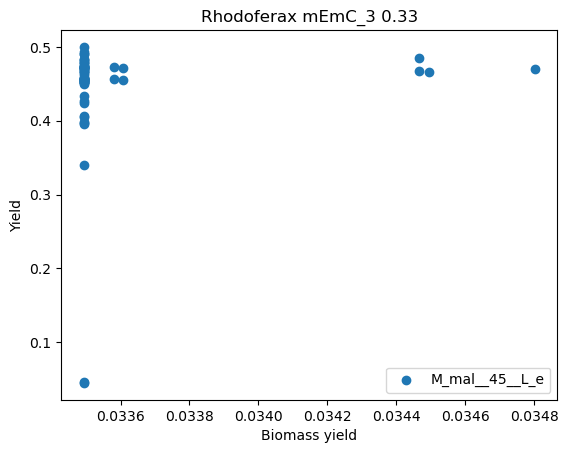

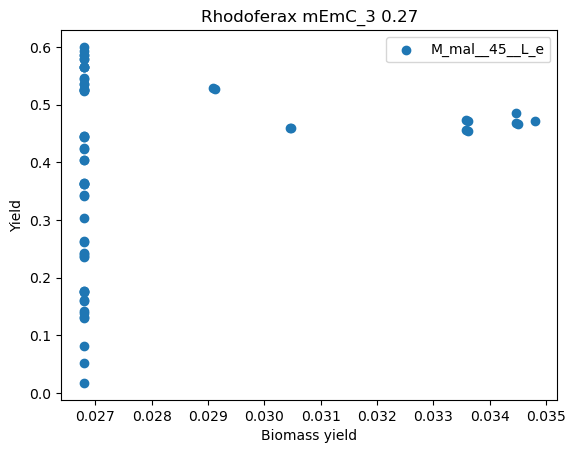

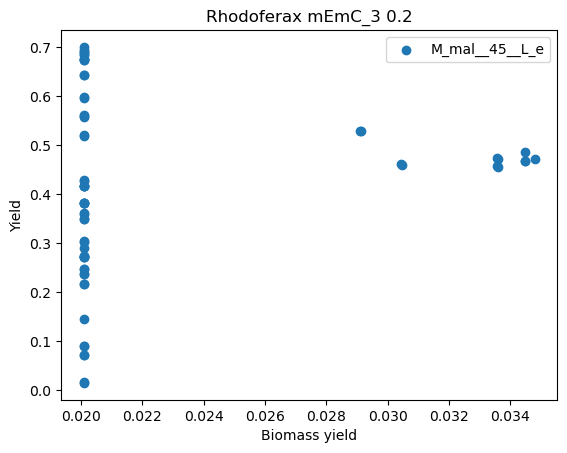

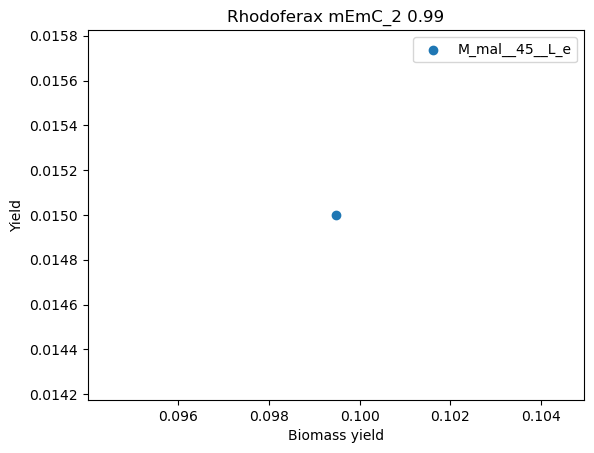

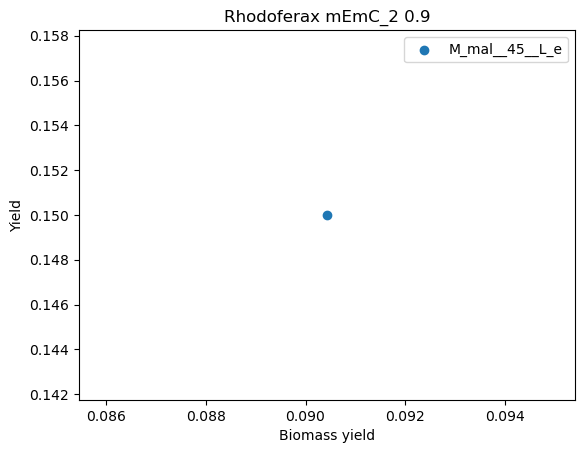

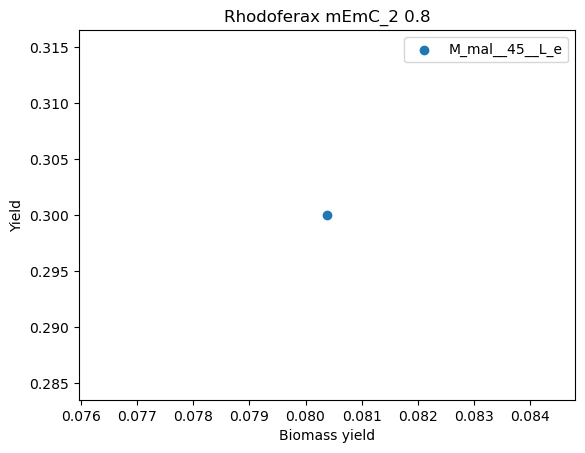

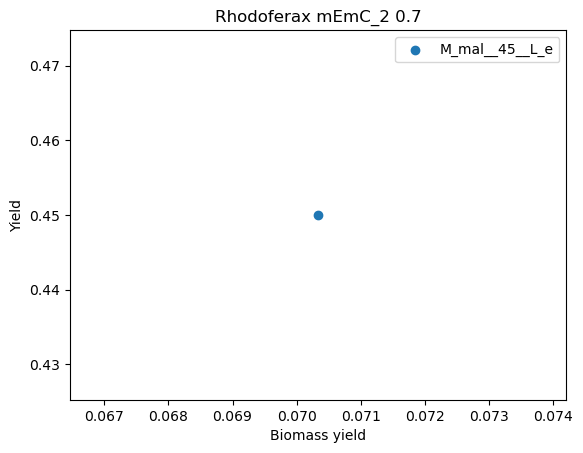

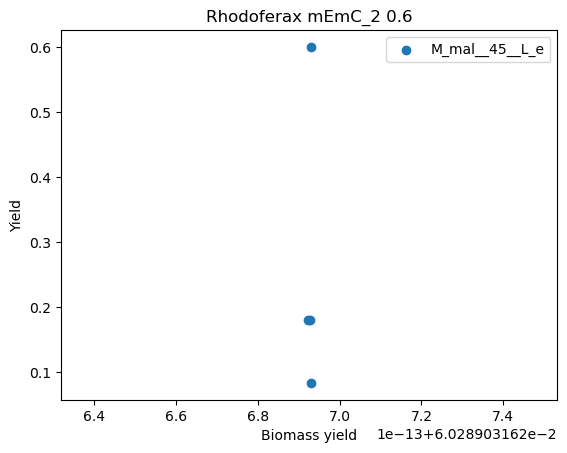

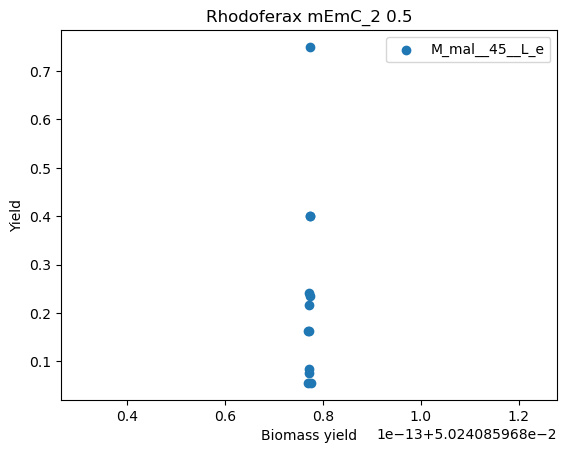

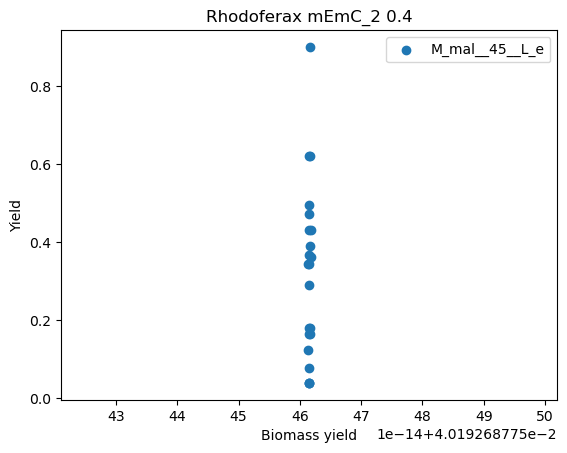

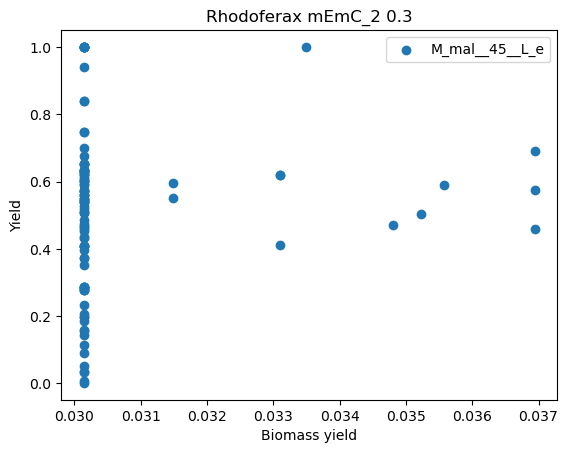

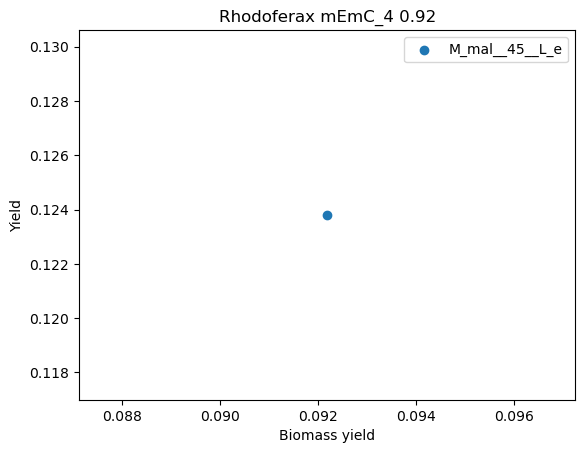

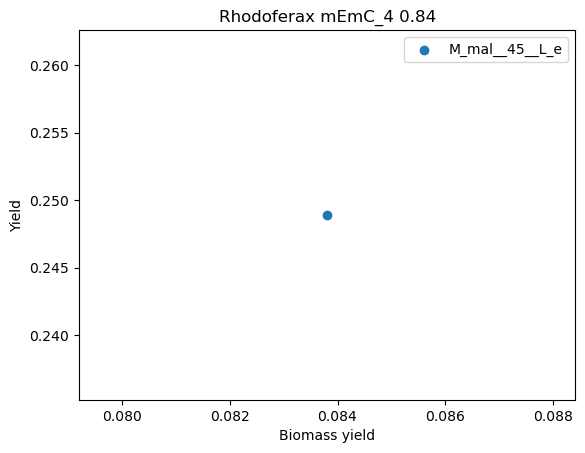

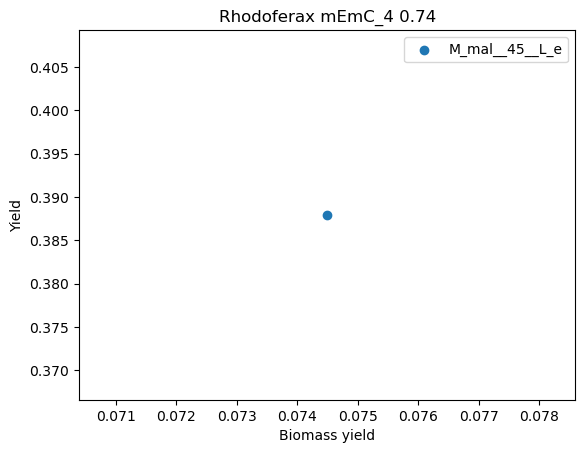

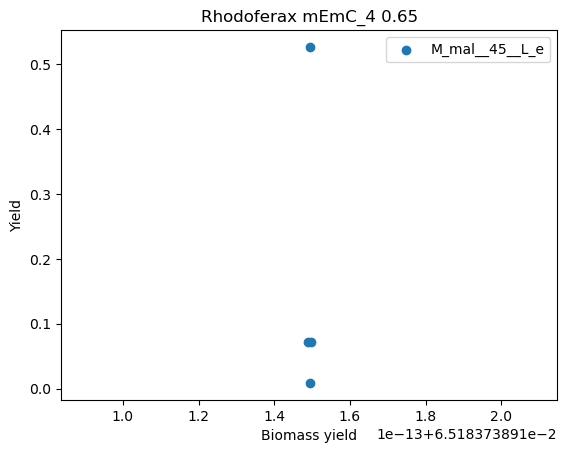

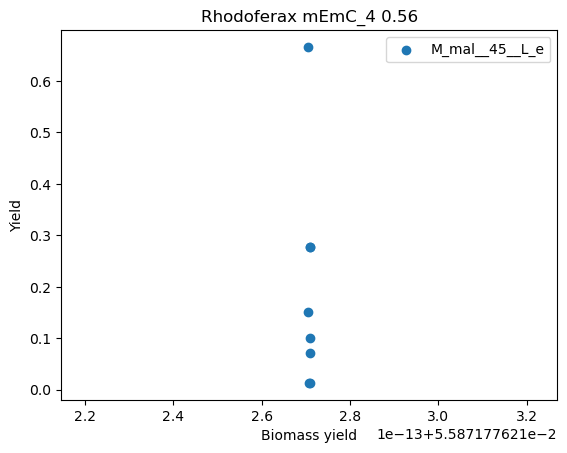

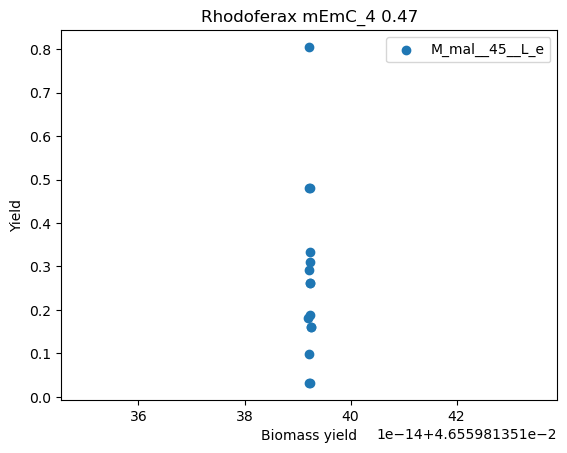

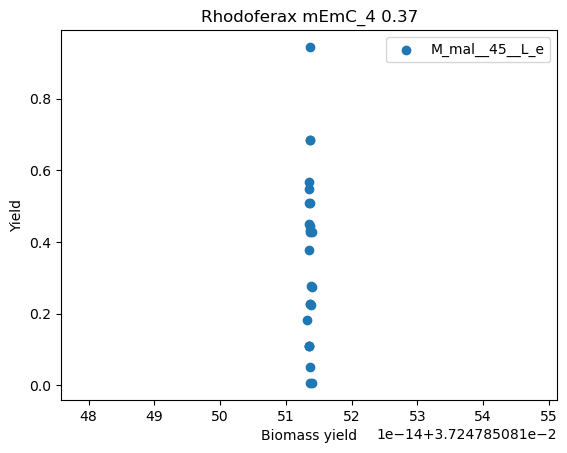

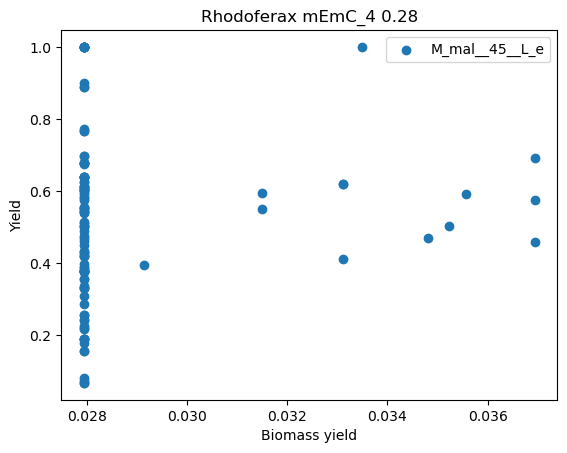

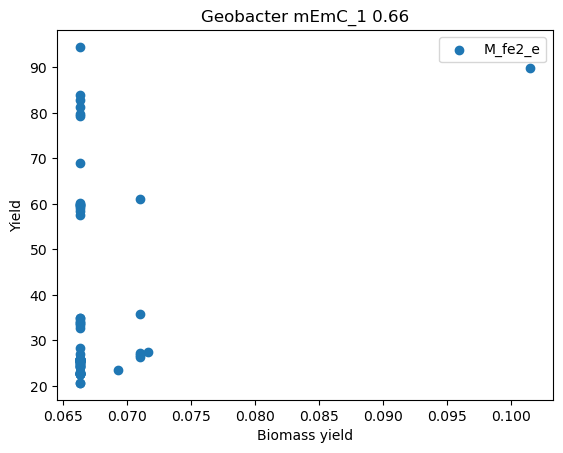

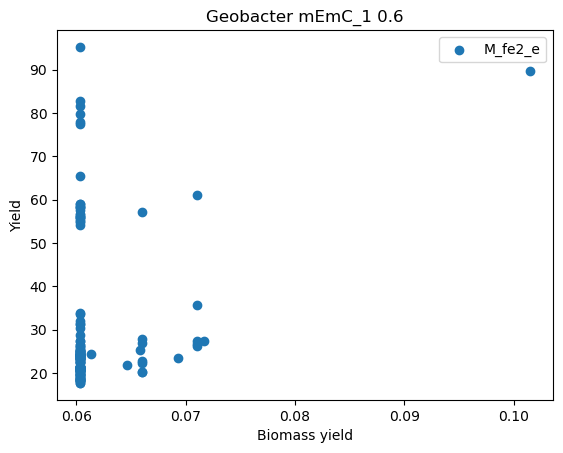

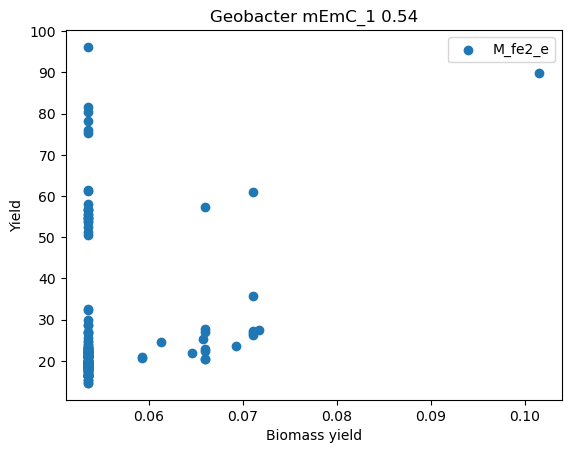

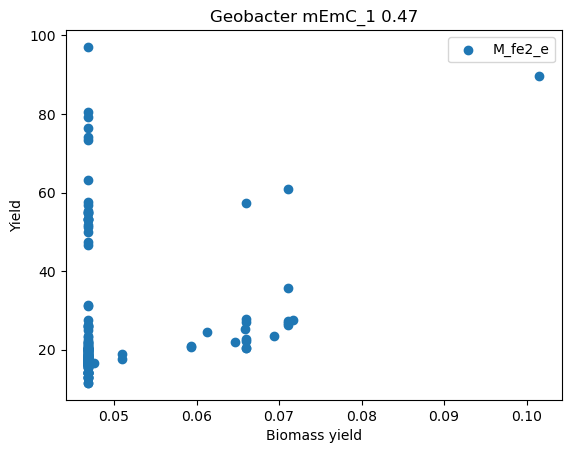

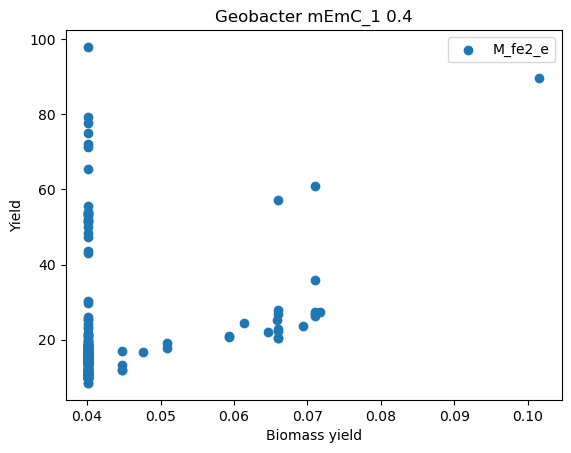

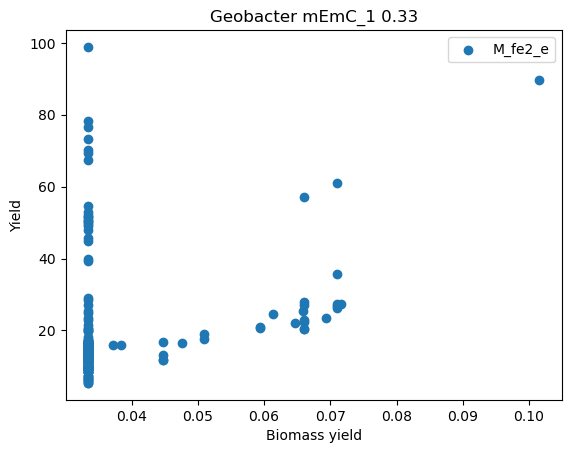

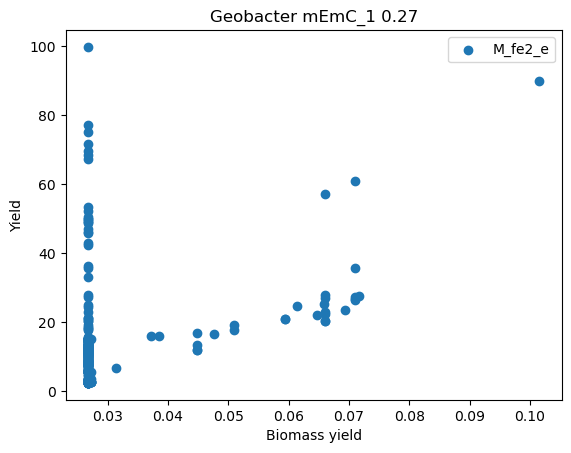

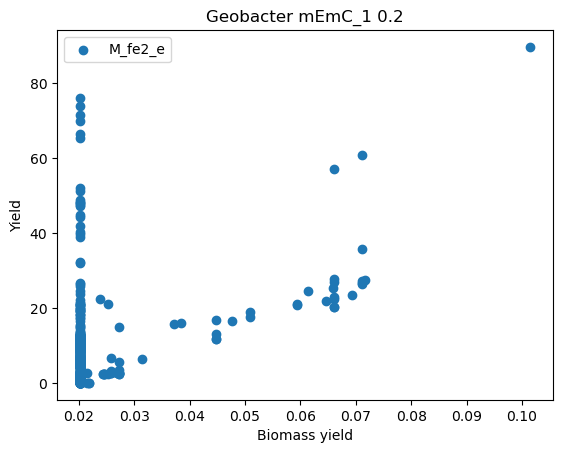

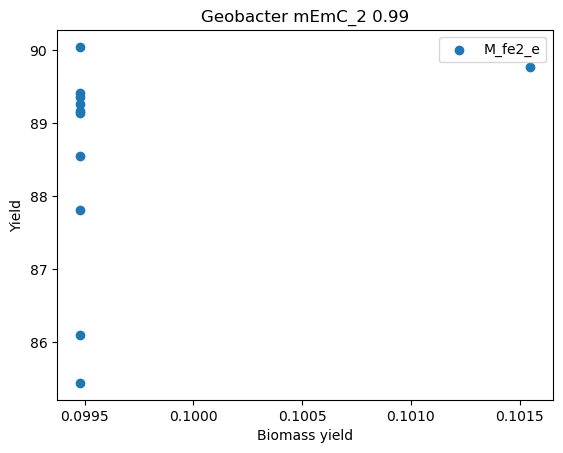

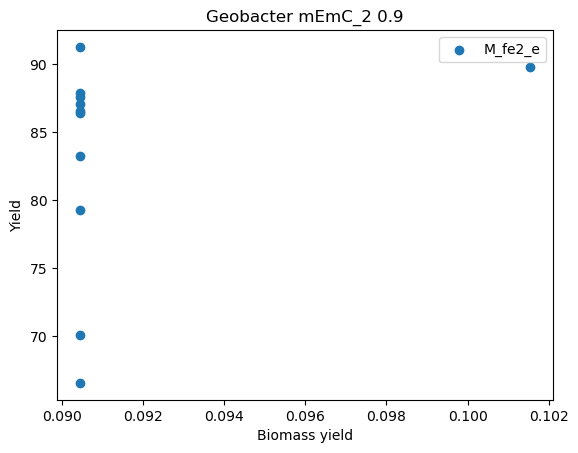

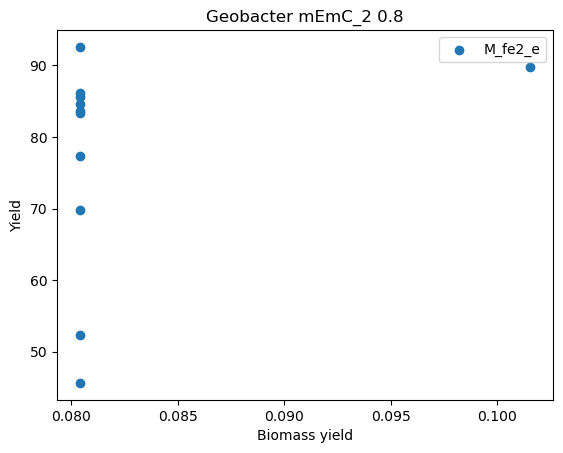

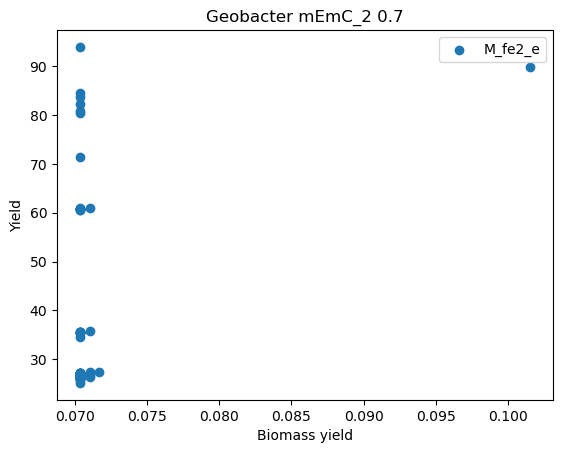

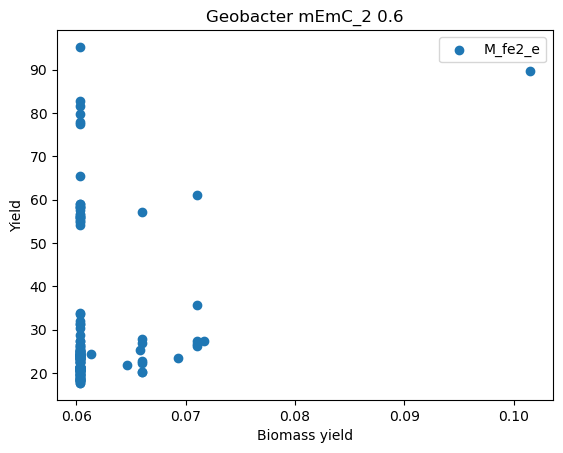

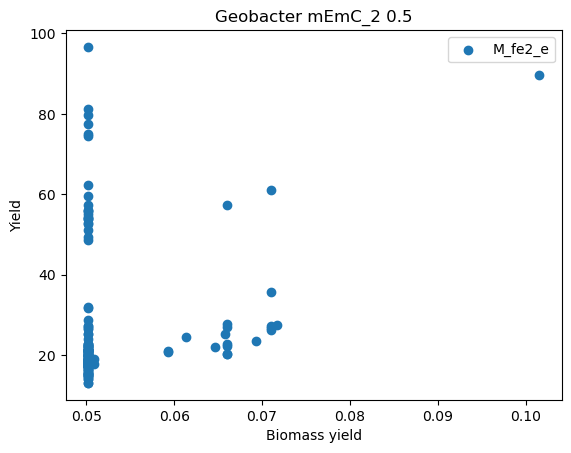

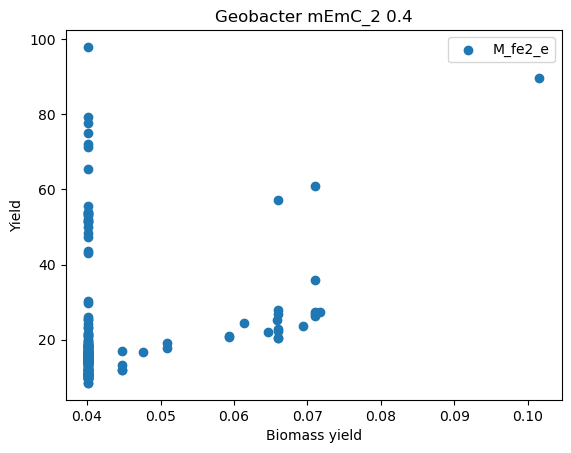

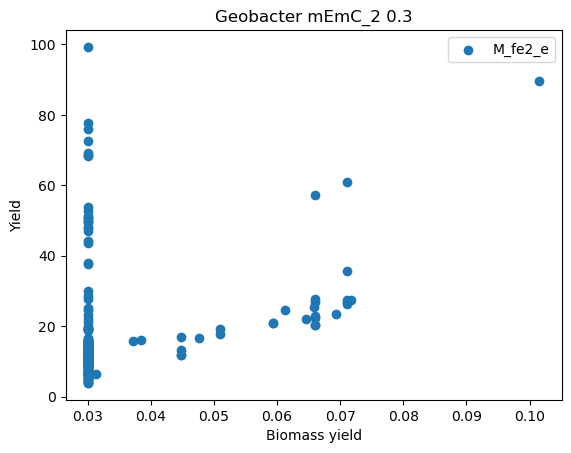

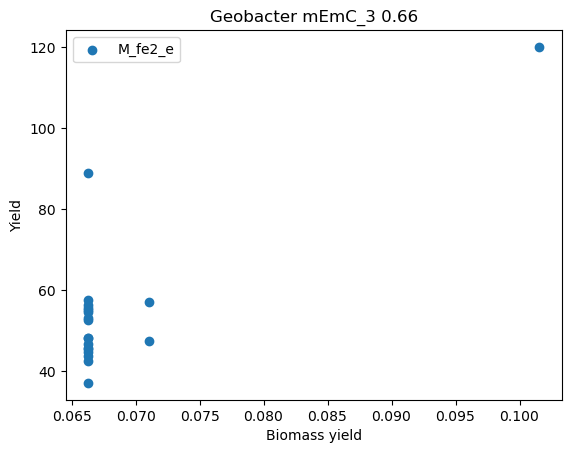

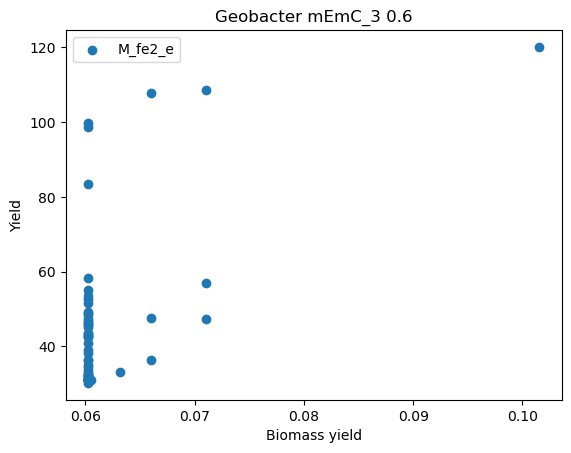

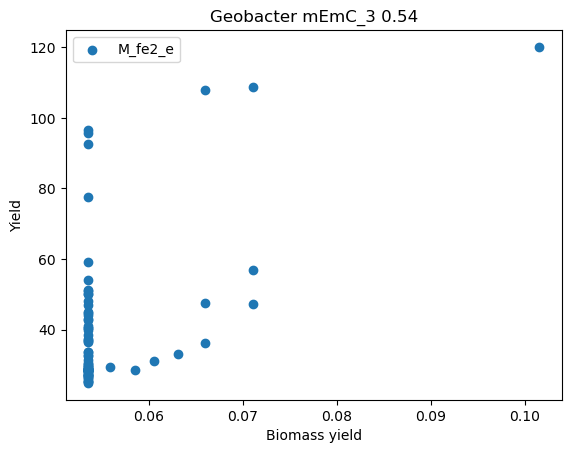

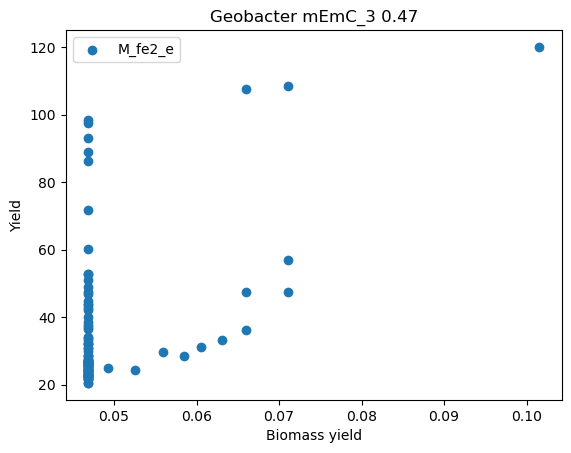

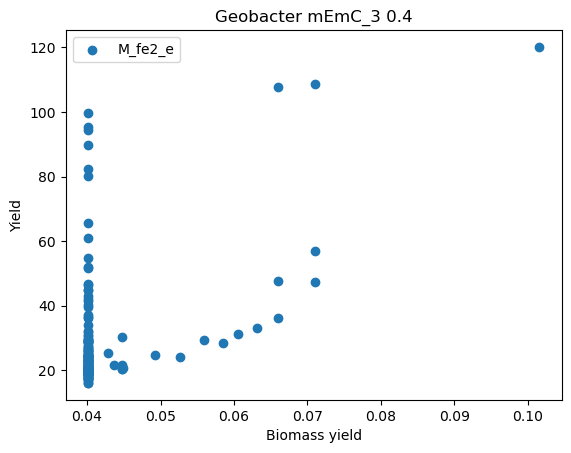

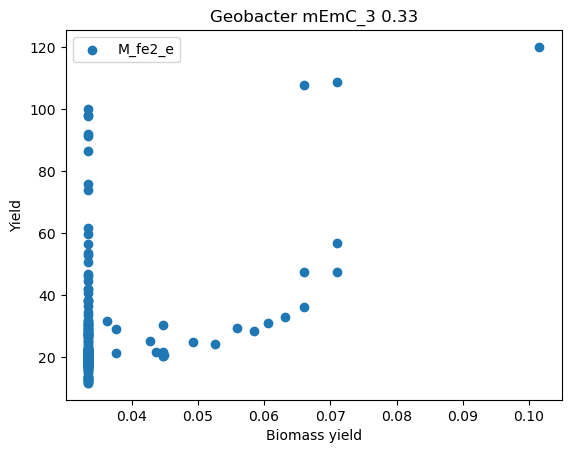

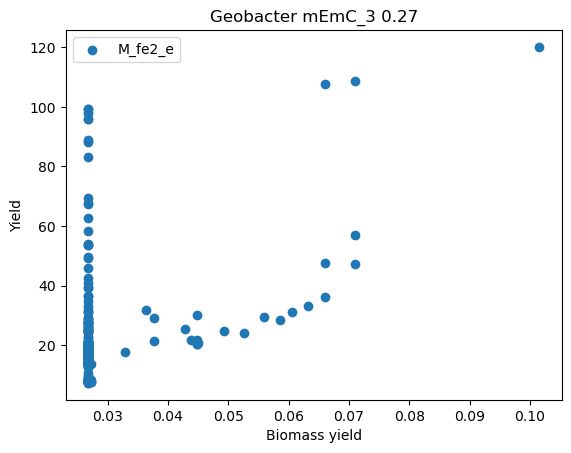

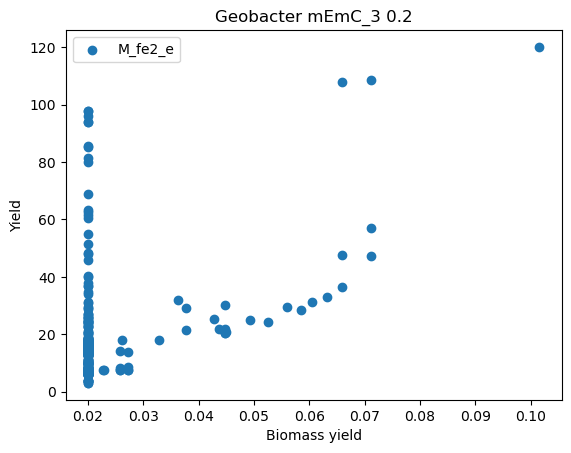

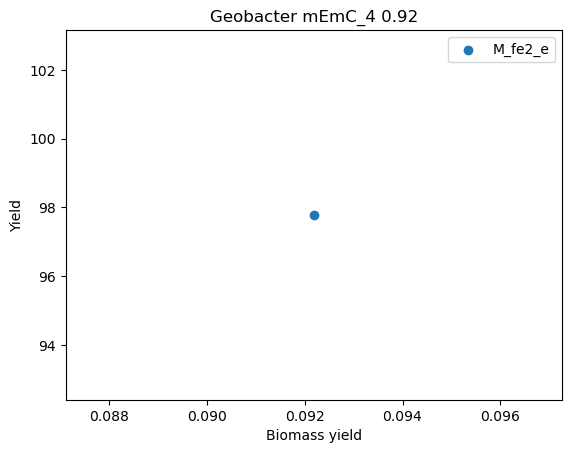

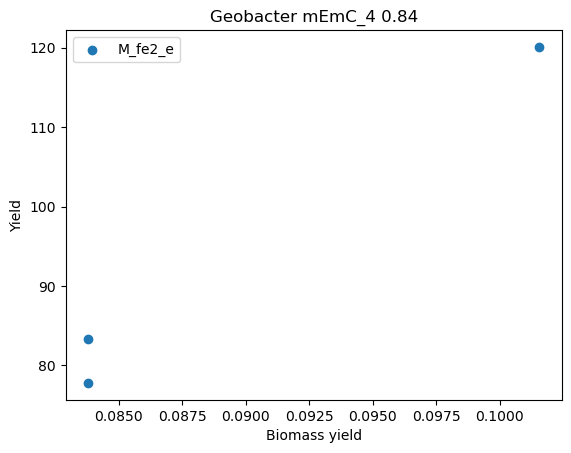

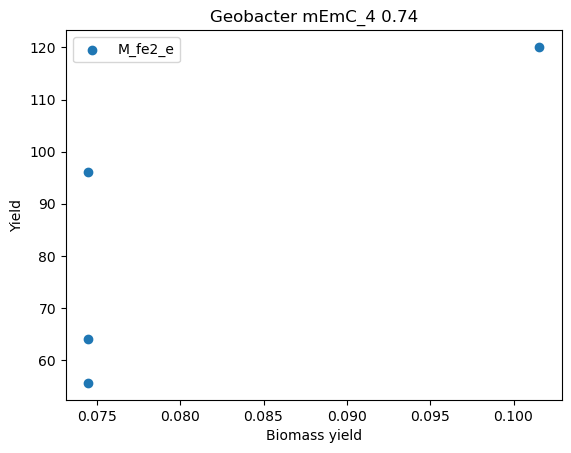

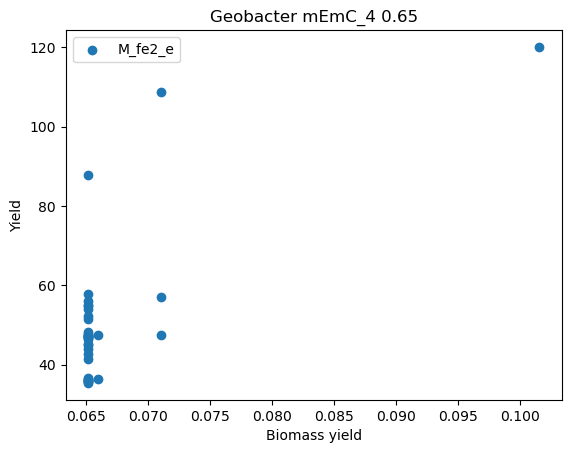

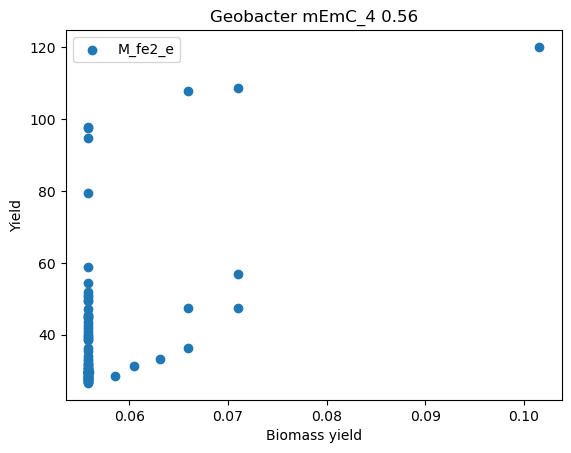

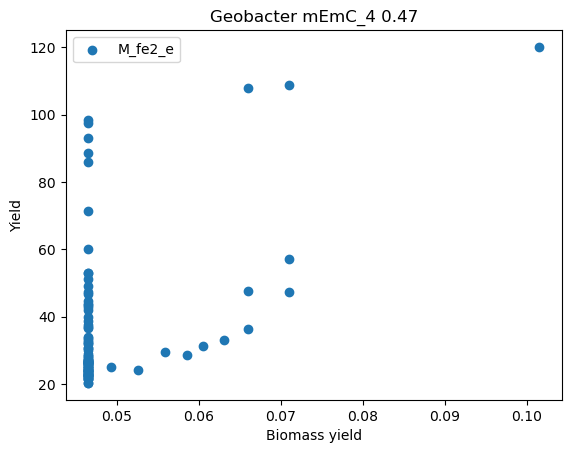

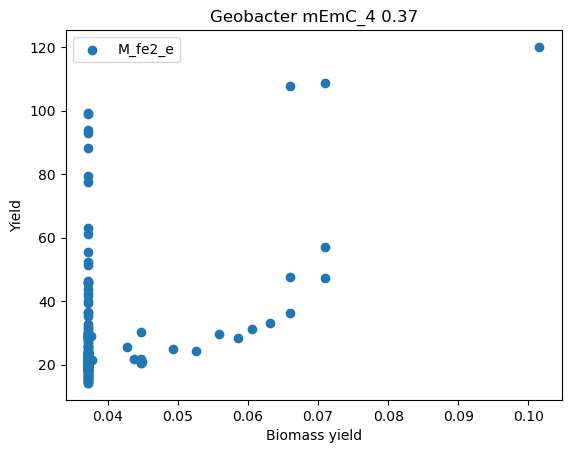

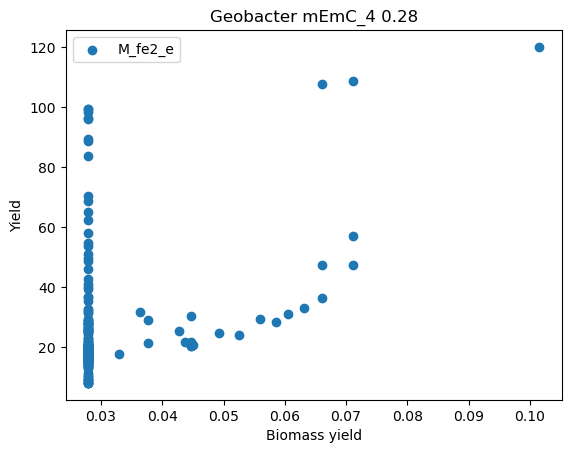

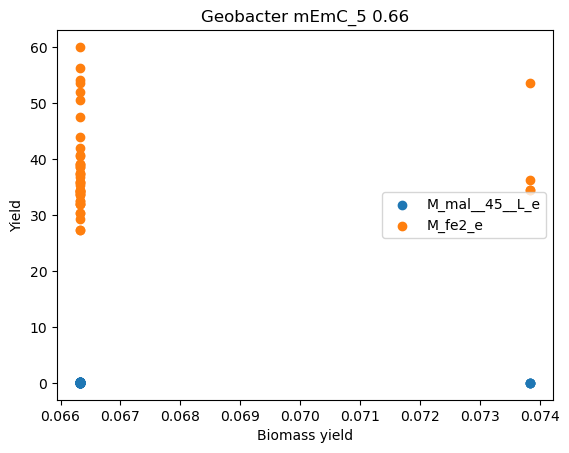

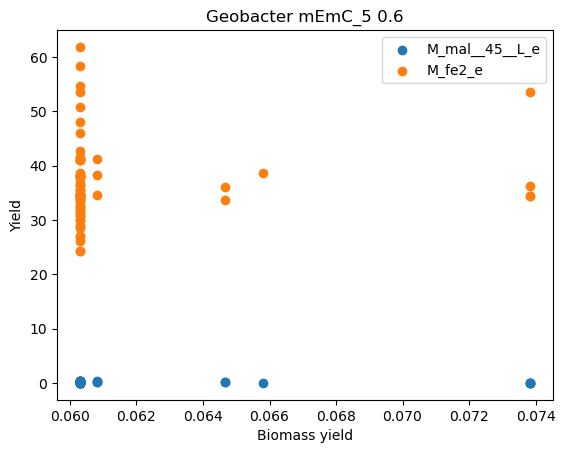

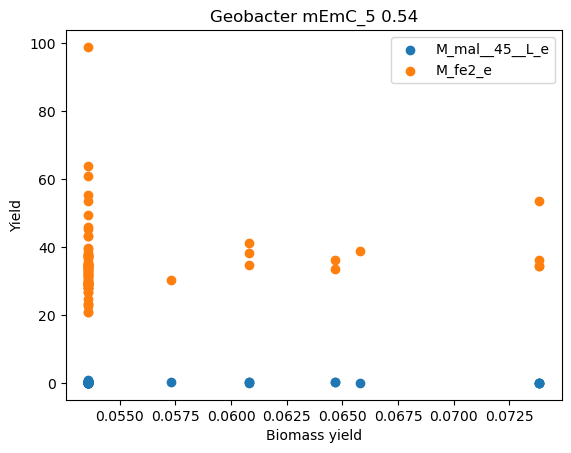

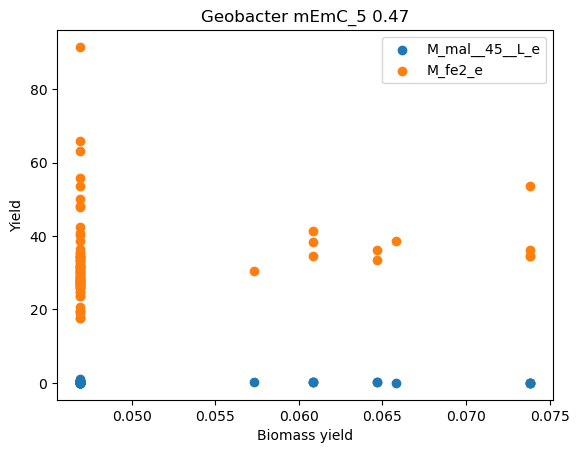

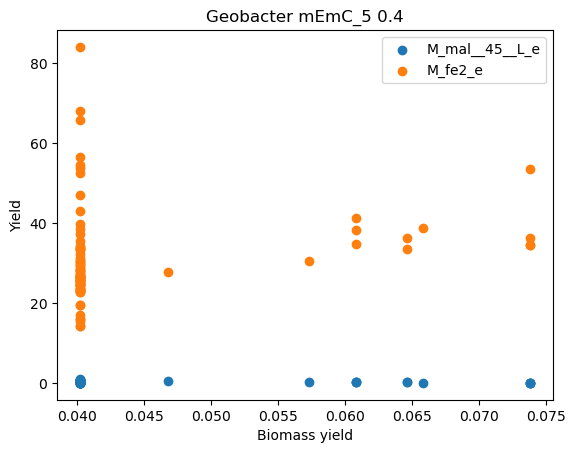

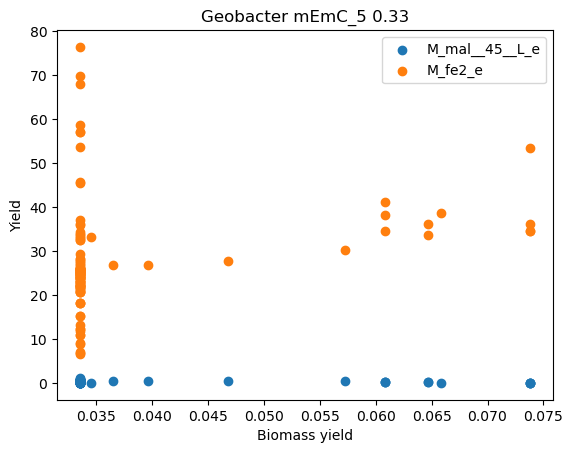

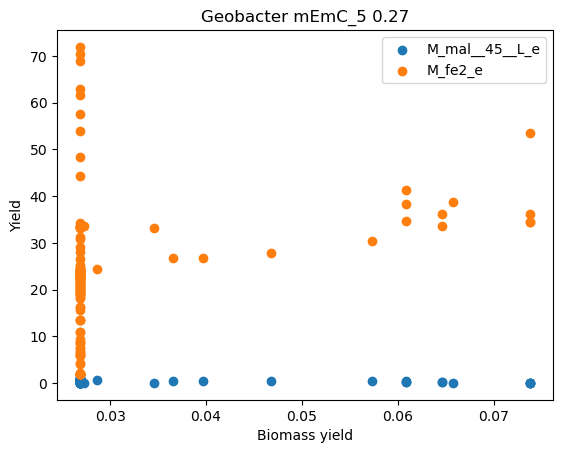

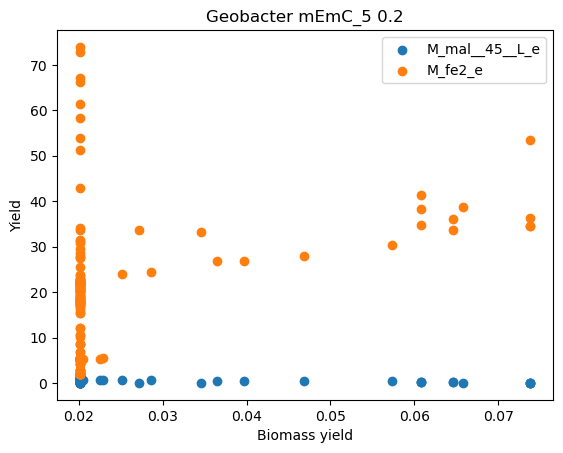

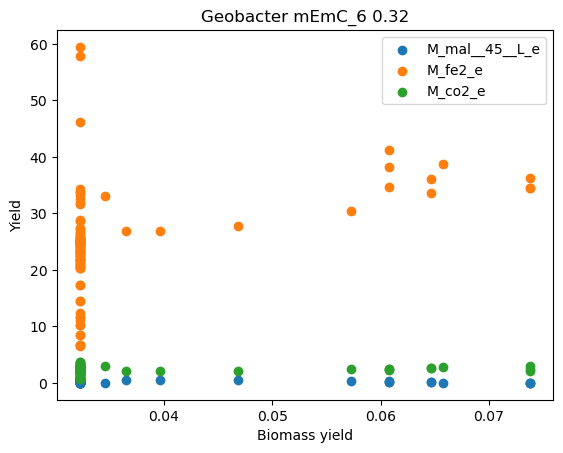

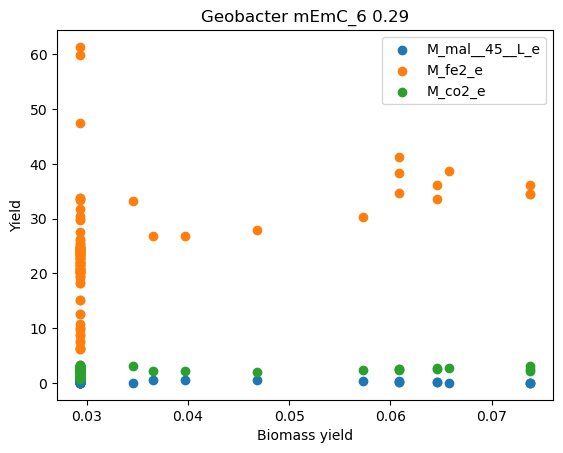

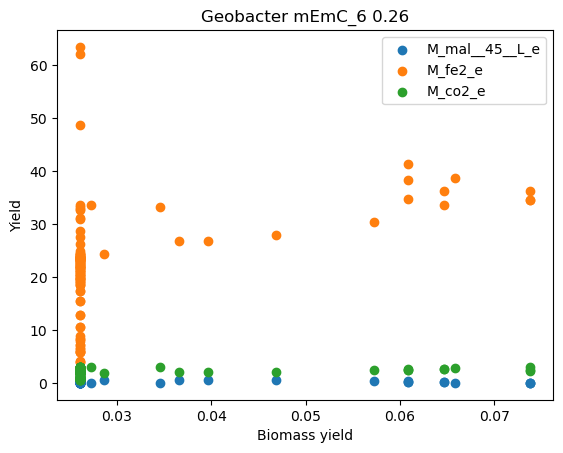

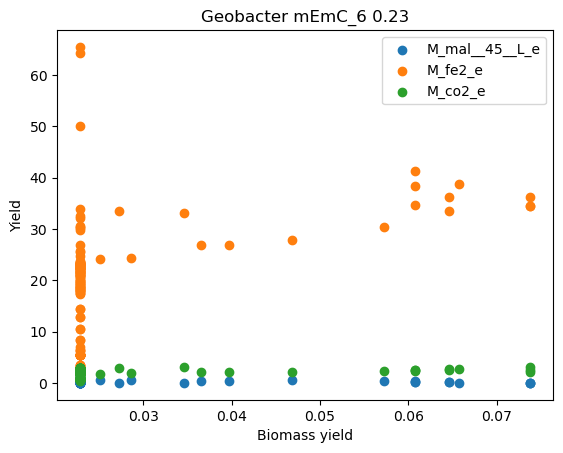

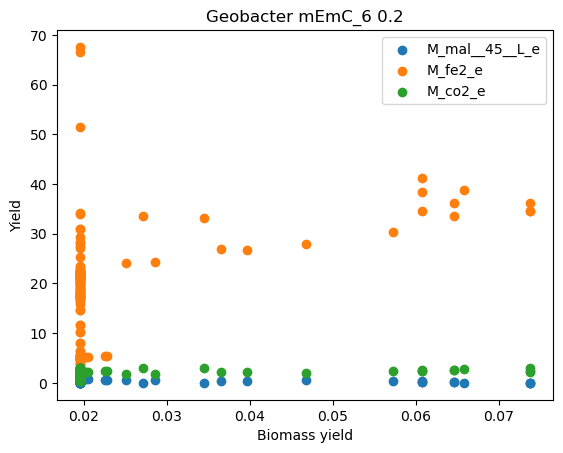

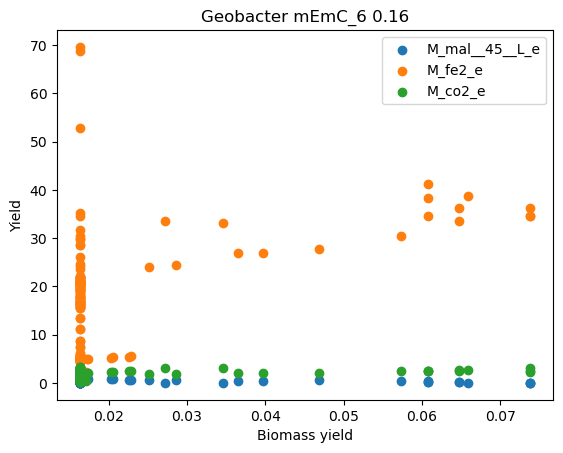

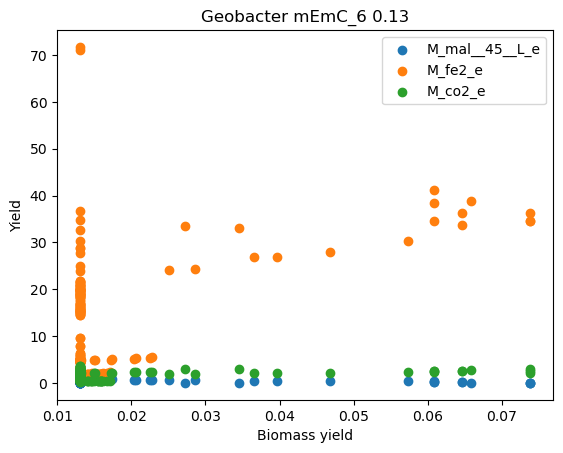

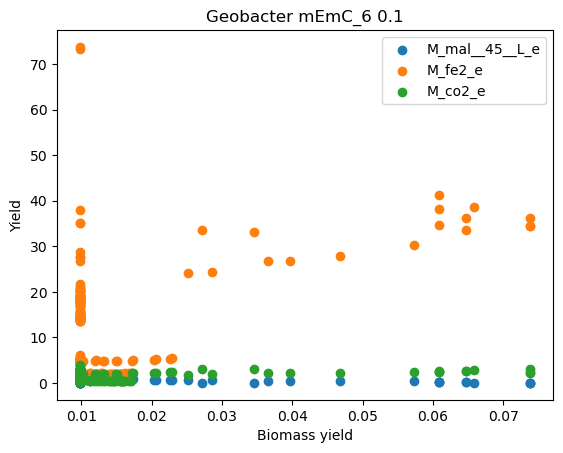

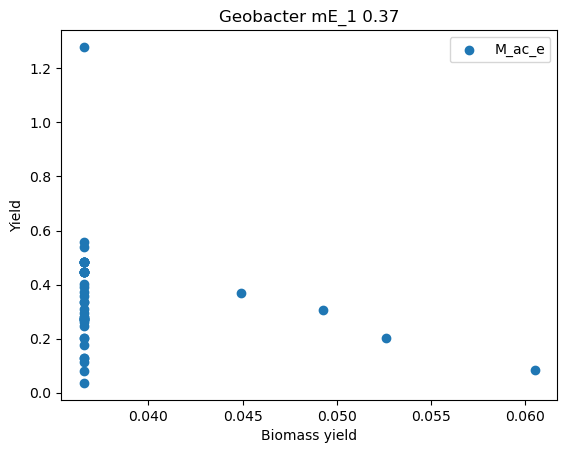

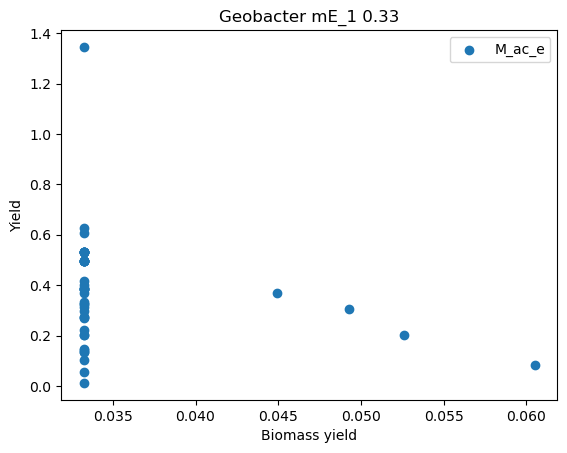

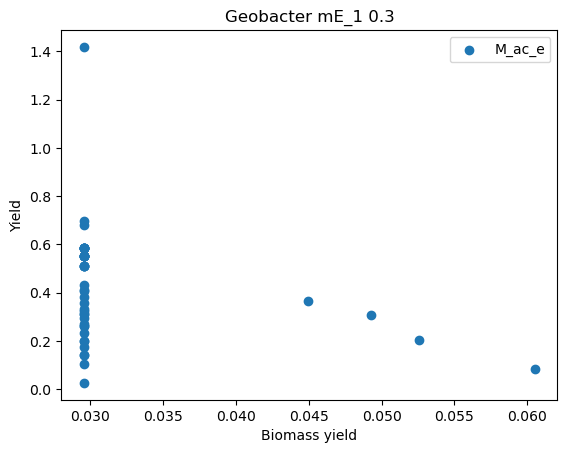

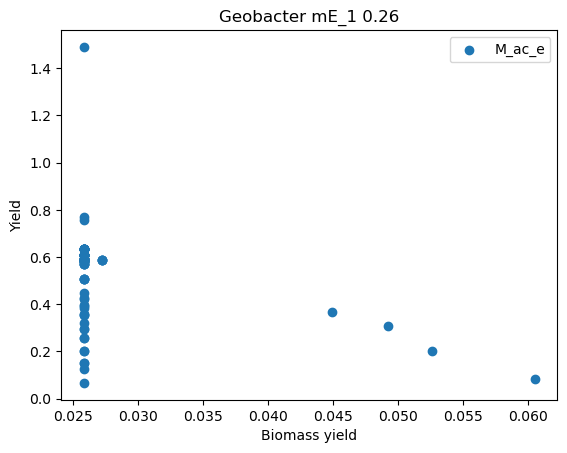

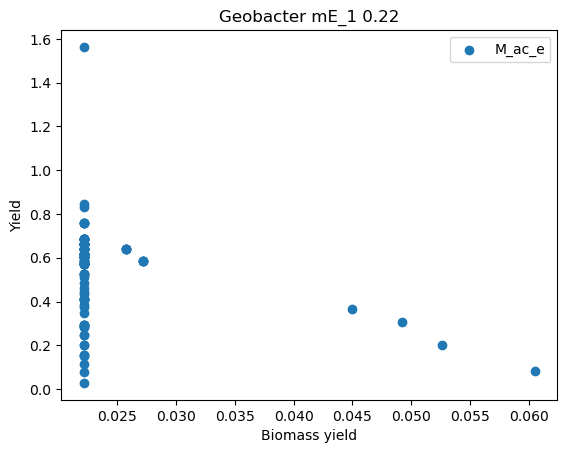

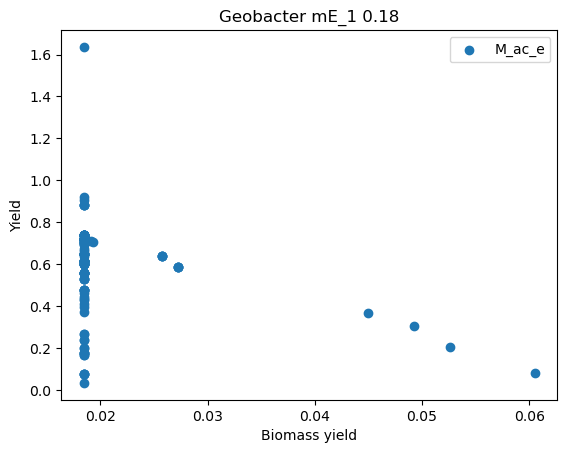

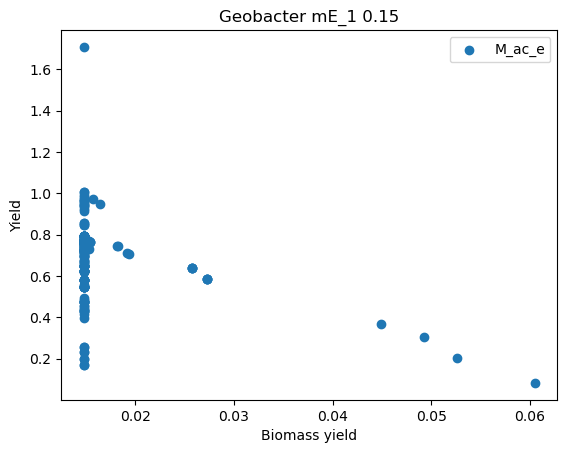

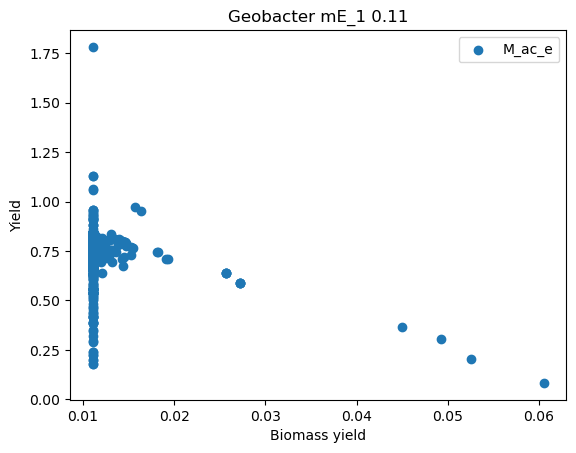

In [8]:
for model, dimes, in all_dimes.items():
    for dime_number, exchanges in dimes.items():
        c = c_sources[model][dime_number]
        sec = exchanges["secretion"]
        if not sec:
            continue
        for mu, ecms in filtered_ecms[model][dime_number].items():

            for met in sec:
                sec_yield = ecms[met]/ecms[c]
                bio_yield = ecms["objective"]/ecms[c]
                sec_name = re.sub(r"M_|__45__L|_e", "", met)

                plt.scatter(abs(bio_yield), abs(sec_yield), label=sec_name)
                plt.xlabel("Biomass yield")
                plt.ylabel("Yield")
                plt.title(f"{model} {dime_number} {mu}")
            plt.legend(sec)
            plt.show()


In [9]:
# for model, dime_ecms in filtered_ecms.items():
#     for dime, X in dime_ecms.items():

#         # 2. Standardize (important!)
#         X_scaled = StandardScaler().fit_transform(X)

#         # 3. Apply PCA
#         pca = PCA(n_components=2)
#         X_pca = pca.fit_transform(X_scaled)
#         var = pca.explained_variance_ratio_

#         plt.figure()
#         yields_dime = X["objective"]/X[c_sources[model][dime]]
#         sc = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=yields_dime)

#         plt.xlabel(f"PC1 ({var[0]*100:.1f}\\%)")
#         plt.ylabel(f"PC2 ({var[1]*100:.1f}\\%)")
#         plt.title(f"PCA {model} DiME {dime}")

#         met_name = re.sub(r"M_|__45__L|_e", "", c_sources[model][dime])
#         plt.colorbar(sc, label=f"Biomass yield on {met_name}")
#         plt.show()


In [10]:
def combine_ecms(ecms1, ecms2, allowed_uptakes):
    df1_t = ecms1.T
    df2_t = ecms2.T

    # 2. Get the union of all keys (rows) and fill missing with 0
    all_keys = df1_t.index.union(df2_t.index)
    df1_ext = df1_t.reindex(all_keys, fill_value=0)
    df2_ext = df2_t.reindex(all_keys, fill_value=0)

    # 3. Combine side‑by‑side (as columns)
    combined = pd.concat([df1_ext, df2_ext], axis=1, keys=["df1", "df2"])
    combined = combined[combined.index != "objective"]

    # Number all columns and split numbering by source
    n1 = df1_ext.shape[1]  # number of columns from df1
    n2 = df2_ext.shape[1]  # number of columns from df2

    new_cols = (
        [f"ECM1-{i+1}" for i in range(n1)] +
        [f"ECM2-{i+1}" for i in range(n2)]
    )
    combined.columns = new_cols

    # Create identity matrix as DataFrame
    identity = pd.DataFrame(
        -np.eye(len(combined)),           # n×n identity matrix
        index=combined.index, # same row index as combined
        columns=combined.index
    )
    # if the index is in allowed_uptakes, the entry in the matrix should be positive, otherwise negative
    mask = identity.index.isin(allowed_uptakes)
    # identity.loc[mask, mask] *= -1

    # rename columns
    I_cols = [f"S_{i.replace('M_', '')}" for i in combined.index]
    identity.columns = I_cols
    
    # Concatenate ECM columns and identity side‑by‑side
    combined_slack = pd.concat([combined, identity], axis=1)

    return combined, combined_slack

In [11]:
combos = {"mEmC_1": ["M_mal__45__L_e", "M_fe2_e"],
          "mEmC_2": ["M_mal__45__L_e", "M_fe2_e"],
          "mEmC_3": ["M_mal__45__L_e", "M_fe2_e"],
          "mEmC_4": ["M_mal__45__L_e", "M_fe2_e"],
          "mEmC_5": ["M_mal__45__L_e", "M_fe2_e"],
          "mEmC_6": ["M_mal__45__L_e", "M_co2_e",  "M_fe2_e"],
          "mE_1": ["M_ac_e"]}
         

In [12]:
efmtool_inputs = {}

for dime_number, crossfed in combos.items():
    efmtool_inputs[dime_number] = {}

    for mu, ecms_geo in filtered_ecms["Geobacter"][dime_number].items():
        ecms_rho = filtered_ecms["Rhodoferax"][dime_number][mu]

        medium_geo = set(ecms_geo.columns[(ecms_geo < 0).any(axis=0)])
        medium_rho = set(ecms_rho.columns[(ecms_rho < 0).any(axis=0)])
        
        allowed_uptakes = (medium_geo | medium_rho) - set(crossfed)
    
        combined, combined_slack = combine_ecms(ecms_geo, ecms_rho, allowed_uptakes)
    
        matrix = np.array(combined_slack)
        mets = list(combined.index)
        rxns = list(combined_slack.columns)
        revs = [0] * combined.shape[1]
        for met in combined_slack.index:
            if met in allowed_uptakes:
                revs.append(1)
            else:
                revs.append(0)

        efmtool_inputs[dime_number][mu] = (matrix, revs, rxns, mets)

In [13]:
# df = pd.DataFrame(efmtool_inputs["mEmC_1"][0.2][0],
#                   columns = efmtool_inputs["mEmC_1"][0.2][2],
#                   index = efmtool_inputs["mEmC_1"][0.2][3])
# df.to_csv("efmtool_input.csv")

In [15]:
options = efmtool.get_default_options()
options['level'] = 'WARNING'

# slow: mEmC_1 0.2, mEmC_3 0.2

for dime_number, one_dime in efmtool_inputs.items():
    mus = sorted((float(k) for k in one_dime.keys()), reverse=True)
    for index, mu in enumerate(mus):
        if index > 7:
            continue
        if dime_number in ["mEmC_1", "mEmC_3", "mEmC_6"]:
            continue
                
        print(f"Running {dime_number} {mu}")

        try:
            _ = pd.read_csv(f"results/ecms2comp_{dime_number}_{mu}.csv")
            print(" * already done")
            continue
        except FileNotFoundError:
            pass

        matrix, revs, rxns, mets = one_dime[mu]
        efms_array = efmtool.calculate_efms(matrix, revs, rxns, mets, options)
        
        print(f"{efms_array.shape[1]} EFMs")
        
        efms_nice = pd.DataFrame(efms_array, index=rxns)
        efms_nice = efms_nice.div(efms_nice.loc["S_virtual_tag_R_constraint_reaction"])
        if index == 0:
            efms_nice.to_csv(f"results/ecms2exs_{dime_number}_{mu}.csv")
        
        efms = efms_nice[efms_nice.index.str.startswith("ECM")]
        ecm1_frac = efms[efms.index.str.startswith("ECM1")].sum(axis=0)
        ecm2_frac = efms[efms.index.str.startswith("ECM2")].sum(axis=0)
        
        composition = pd.DataFrame({
            "Geobacter": ecm1_frac,
            "Rhodoferax": ecm2_frac
        })
        
        composition.to_csv(f"results/ecms2comp_{dime_number}_{mu}.csv")

Running mEmC_2 0.99
 * already done
Running mEmC_2 0.9
 * already done
Running mEmC_2 0.8
 * already done
Running mEmC_2 0.7
 * already done
Running mEmC_2 0.6
 * already done
Running mEmC_2 0.5
 * already done
Running mEmC_2 0.4
 * already done
Running mEmC_2 0.3
 * already done
Running mEmC_4 0.92
 * already done
Running mEmC_4 0.84
 * already done
Running mEmC_4 0.74
 * already done
Running mEmC_4 0.65
 * already done
Running mEmC_4 0.56
 * already done
Running mEmC_4 0.47
 * already done
Running mEmC_4 0.37
 * already done
Running mEmC_4 0.28
 * already done
Running mEmC_5 0.66
 * already done
Running mEmC_5 0.6
 * already done
Running mEmC_5 0.54
 * already done
Running mEmC_5 0.47
 * already done
Running mEmC_5 0.4
 * already done
Running mEmC_5 0.33
 * already done
Running mEmC_5 0.27
 * already done
Running mEmC_5 0.2
 * already done
Running mE_1 0.37
 * already done
Running mE_1 0.33
 * already done
Running mE_1 0.3
 * already done
Running mE_1 0.26
 * already done
Running mE_


Exception: java.lang.OutOfMemoryError thrown from the UncaughtExceptionHandler in thread "Python Reference Queue"
Error running the efmtool Java process:
Traceback (most recent call last):
  File "JobScheduleMultiThreadTreeFactory.java", line 64, in ch.javasoft.metabolic.efm.adj.incore.tree.JobScheduleMultiThreadTreeFactory.createInterNode
Exception: Java Exception

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/home/users/dszeliova/.conda/envs/comms2/lib/python3.11/site-packages/efmtool/efmtool.py", line 149, in _efmtool_process
    CalculateFluxModes.matlab(args)
java.lang.java.lang.OutOfMemoryError: java.lang.OutOfMemoryError: Java heap space

EFM computation failed.


RuntimeError: Error running the efmtool Java process

In [ ]:
matrix = np.array([[-1, 0, -1, 0, 0],
                   [1, -1, 0, -1, 0],
                   [0, 1, 0, 0, -1]])
revs = [0,0,1,0,0]
mets = ["A", "B", "C"]
rxns = ["ECM1", "ECM2", "SA", "SB", "SC"]

In [ ]:
efms = efmtool.calculate_efms(matrix, revs, rxns, mets, options)
pd.DataFrame(efms, index = rxns)

In [ ]:
matrix = np.array([[-1, -1, 0, -1, 0, 0],
                   [1, 0.5, -1, 0, -1, 0],
                   [0, 0.5, 1, 0, 0, -1]])
revs = [0,0,0,1,0,0]
mets = ["A", "B", "C"]
rxns = ["ECM11", "ECM12", "ECM2", "SA", "SB", "SC"]

In [ ]:
efms = efmtool.calculate_efms(matrix, revs, rxns, mets, options)
pd.DataFrame(efms, index = rxns)